# Notebook de preprocesamiento

Recibe los datos crudos y retorna los datos limpios, transformados y divididos para realizar luego el entrenamiento de los modelos.

In [27]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder


import joblib

from sklearn.model_selection import train_test_split

In [28]:
# LOAD DATA
train = pd.read_csv("../data/raw/train.csv")

X = train.drop(columns=["SalePrice"])
y = train["SalePrice"]


with pd.option_context('display.max_columns', None, 'display.width', None, 'display.max_colwidth', None):
    display(X.head(10))


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,Y,SBrkr,1077,0,0,1077,1,0,1,0,2,2,TA,5,Typ,2,TA,Attchd,1939.0,RFn,1,205,G

## Inputación datos faltantes

In [29]:
# Missing values
missing = X.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(X)) * 100

missing_df = pd.DataFrame({
    "missing": missing,
    "pct": missing_pct
})

missing_df.head(20)

,missing,pct
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageQual,81,5.547945
GarageFinish,81,5.547945


In [30]:
# algunas verificaciones para decidir qué hacer con los valores faltantes

# Casos donde MasVnrArea es NaN PERO sí hay tipo (inconsistencia)
inconsistencias = X[
    (X["MasVnrArea"].isna()) & 
    (X["MasVnrType"] != "None")
]

print("Número de inconsistencias:", len(inconsistencias))
inconsistencias[["MasVnrType", "MasVnrArea"]]

Número de inconsistencias: 8


,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
650,NaN,NaN
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1243,NaN,NaN
1278,NaN,NaN


In [31]:
X['Electrical'].value_counts()

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

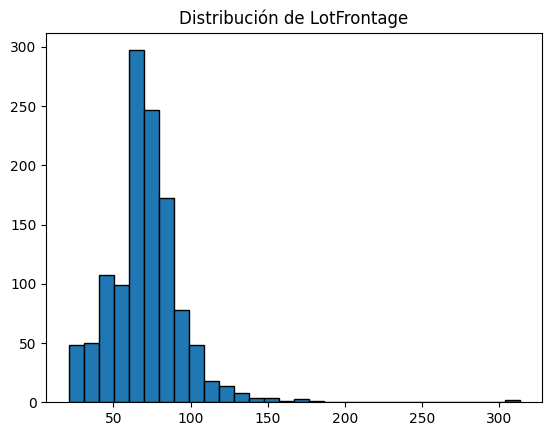

In [32]:
# histograma de la variable LotFrontage
import matplotlib.pyplot as plt
plt.hist(X['LotFrontage'].dropna(), bins=30, edgecolor='k')
plt.title('Distribución de LotFrontage')
plt.show()

In [33]:
X['LotFrontage'].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

## Pipeline de preprocesamiento

In [34]:
def drop_high_na_rows(X, threshold=0.3):
    mask = X.isnull().mean(axis=1) < threshold
    return X.loc[mask]


In [35]:
# Tratamiento de variables con datos faltantes y mapeo de categorías
class ManualImputer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # =========================
        # QUAL ORDINALS 
        # =========================
        qual_cols = [
            "ExterQual","ExterCond","BsmtQual","BsmtCond",
            "HeatingQC","KitchenQual","FireplaceQu",
            "GarageQual","GarageCond","PoolQC"
        ]
        
        for col in qual_cols:
            X[col] = X[col].fillna("NA")
        
        # =========================
        # NONE CATEGORIES (verdadero "no existe")
        # =========================
        none_cols = [
            "MiscFeature","Alley", "MasVnrType"
        ]
        
        for col in none_cols:
            X[col] = X[col].fillna("None")
        
        # =========================
        # BASEMENT 
        # =========================
        bsmt_cols = [
            "BsmtExposure","BsmtFinType1","BsmtFinType2"
        ]
        
        for col in bsmt_cols:
            X[col] = X[col].fillna("NA")
        
            
        # GARAGE
        # =========================
        X["HasGarage"] = X["GarageType"].notnull().astype(int)
        
        X["GarageYrBlt"] = X["GarageYrBlt"].fillna(X["YearBuilt"])
    
        # GarageFinish
        X["GarageFinish"] = X["GarageFinish"].fillna("NA")
        
        # =========================
        # MasVnrArea
        # =========================
        X["MasVnrArea"] = X["MasVnrArea"].fillna(0)
        
        # =========================
        # Electrical (1 missing)
        # =========================
        X["Electrical"] = X["Electrical"].fillna(X["Electrical"].mode()[0])
        
        # =========================
        # LotFrontage (por Neighborhood)
        # =========================
        X["LotFrontage"] = X.groupby("Neighborhood")["LotFrontage"]\
                           .transform(lambda x: x.fillna(x.median()))
        
        return X

## Feature Engineering

Creación variable TotalSF (total de metros cuadrados)

In [36]:
class CustomFeatures(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        X["TotalSF"] = (
            X["TotalBsmtSF"] +
            X["1stFlrSF"] +
            X["2ndFlrSF"]
        )
        
        return X

## Estandarización y codificación one hot 
Estandarización de las variables numéricas y codificación de las variables categóricas tipo one hot encoder. Imputación para datos nuevos y otros no considerados previamente.


In [37]:
ordinal_cols = [
    # CALIDAD
    "ExterQual","ExterCond","BsmtQual","BsmtCond",
    "HeatingQC","KitchenQual","FireplaceQu",
    "GarageQual","GarageCond","PoolQC",
    
    # BASEMENT
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    
    # GARAGE
    "GarageFinish",
    
    # FUNCIONALIDAD
    "Functional",
    
    # EXTERIOR / LOTE
    "PavedDrive",
    "LandSlope",
    "LotShape"
]

ordinal_categories_map = {

    # CALIDAD
    "ExterQual": ["NA","Po","Fa","TA","Gd","Ex"],
    "ExterCond": ["NA","Po","Fa","TA","Gd","Ex"],
    "BsmtQual": ["NA","Po","Fa","TA","Gd","Ex"],
    "BsmtCond": ["NA","Po","Fa","TA","Gd","Ex"],
    "HeatingQC": ["NA","Po","Fa","TA","Gd","Ex"],
    "KitchenQual": ["NA","Po","Fa","TA","Gd","Ex"],
    "FireplaceQu": ["NA","Po","Fa","TA","Gd","Ex"],
    "GarageQual": ["NA","Po","Fa","TA","Gd","Ex"],
    "GarageCond": ["NA","Po","Fa","TA","Gd","Ex"],
    "PoolQC": ["NA","Fa","TA","Gd","Ex"],

    # BASEMENT
    "BsmtExposure": ["NA","No","Mn","Av","Gd"],
    "BsmtFinType1": ["NA","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],
    "BsmtFinType2": ["NA","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],

    # GARAGE
    "GarageFinish": ["NA","Unf","RFn","Fin"],

    # FUNCIONALIDAD
    "Functional": ["Sal","Sev","Maj2","Maj1","Mod","Min2","Min1","Typ"],

    # EXTERIOR
    "PavedDrive": ["N","P","Y"],
    "LandSlope": ["Gtl","Mod","Sev"],
    "LotShape": ["IR3","IR2","IR1","Reg"]
}


def build_preprocessor(X):
    
    # =========================
    # COLUMN SPLIT
    # =========================
    num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    
    ordinal_cols_used = [c for c in ordinal_cols if c in X.columns]
    nominal_cols = [c for c in cat_cols if c not in ordinal_cols_used]
    
    # =========================
    # NUMERICAL
    # =========================
    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    # =========================
    # NOMINAL
    # =========================
    nominal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    # =========================
    # ORDINAL
    # =========================
    ordinal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            categories=[ordinal_categories_map[col] for col in ordinal_cols_used],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ])
    
    return ColumnTransformer([
        ("num", num_pipeline, num_cols),
        ("nom", nominal_pipeline, nominal_cols),
        ("ord", ordinal_pipeline, ordinal_cols_used)
    ])

In [38]:
def build_pipeline(X):
    
    manual = ManualImputer()
    features = CustomFeatures()
    
    X_temp = manual.fit_transform(X)
    X_temp = features.fit_transform(X_temp)
    
    preprocessor = build_preprocessor(X_temp)
    
    pipeline = Pipeline([
        ("manual_rules", ManualImputer()),
        ("feature_engineering", CustomFeatures()),
        ("preprocessing", preprocessor)
    ])
    
    return pipeline

In [39]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Transformación de target
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

# Limpieza 
X_train = drop_high_na_rows(X_train)
y_train = y_train.loc[X_train.index]

# Guardar datos limpios
X_train.to_csv("../data/clean/X_train.csv", index=False)
X_test.to_csv("../data/clean/X_test.csv", index=False)

y_train.to_csv("../data/clean/y_train.csv", index=False)
y_test.to_csv("../data/clean/y_test.csv", index=False)





In [40]:
X_train_processed = build_pipeline(X_train).fit_transform(X_train)

# Verificación de valores faltantes
missing = pd.isna(X_train_processed).sum(axis=0)
missing_pct = (missing / len(X_train_processed)) * 100

missing_df = pd.DataFrame({
    "missing": missing,
    "pct": missing_pct
})

missing_df

,missing,pct
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0
...,...,...
224,0,0.0
225,0,0.0
226,0,0.0
227,0,0.0
